In [2]:
## Libraries

import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
from fredapi import Fred

import statsmodels.api as sm
import matplotlib.pyplot as plt

### 1 - Initial Setup

In [3]:
# Data loading script

df = pd.read_csv(
    "../data/processed/quarterly_llp_macro.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

# Tell Pandas date is our index 
df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

,llp,unemployment,indpro,recession,term_spread,total_loans,llp_ratio,optimism_index
DATE,,,,,,,,
1986-01-01,4727.716,7.033333,55.355800,0.0,1.448000,1.436639e+06,0.003291,100.513167
1986-04-01,5545.933,7.166667,55.021467,0.0,1.277031,1.463927e+06,0.003788,101.420000
1986-07-01,5254.408,6.966667,55.237800,0.0,1.621406,1.493164e+06,0.003519,99.079233
1986-10-01,7171.896,6.833333,55.857800,0.0,1.761935,1.528918e+06,0.004691,98.987867
1987-01-01,5502.244,6.600000,56.608500,0.0,1.495738,1.577870e+06,0.003487,100.634667


In [4]:
# Sanity check

df.index.min(), df.index.max(), len(df)

(Timestamp('1986-01-01 00:00:00'), Timestamp('2025-10-01 00:00:00'), 160)

In [ ]:
# Rename variables - d = delta

df["dllp"] = df["llp"].diff()
df["dunemp"] = df["unemployment"].diff()
df["dspread"] = df["term_spread"].diff()
df["dindpro"] = df["indpro"].diff()

### 2 - Explore Unemployment vs LLP

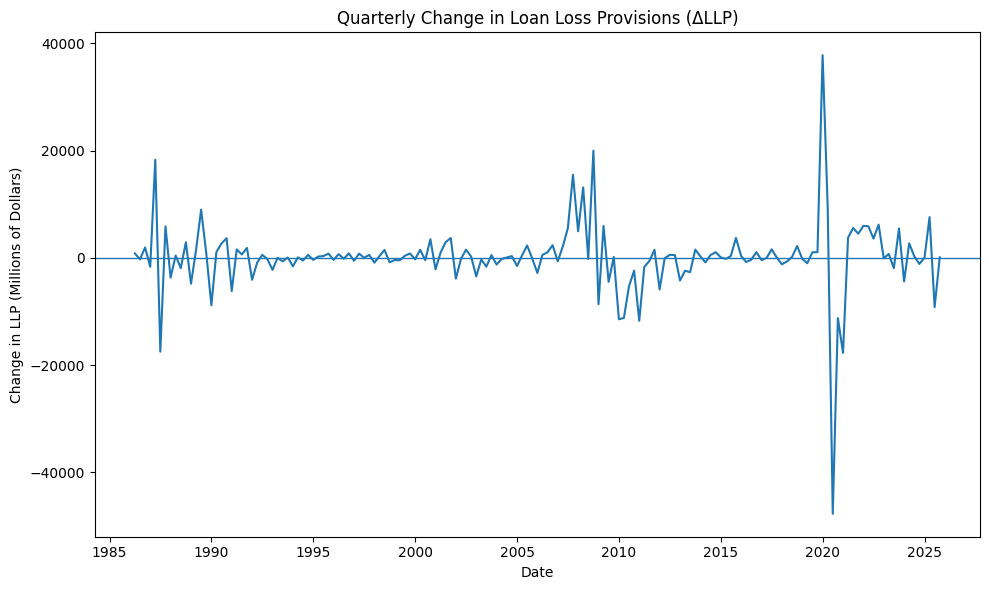

In [6]:
# Delta LLP Plot

plt.figure(figsize=(10,6))
plt.plot(df.index, df["dllp"])
plt.title("Quarterly Change in Loan Loss Provisions (ΔLLP)")
plt.ylabel("Change in LLP (Millions of Dollars)")
plt.xlabel("Date")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

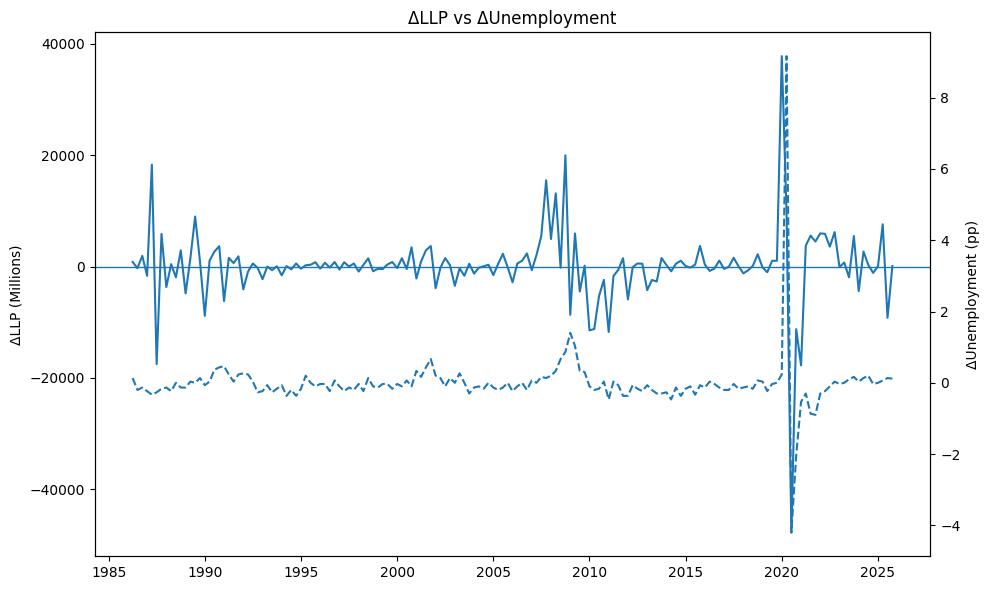

In [7]:
# Overlay Delta LLP onto Delta Unemployment

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(df.index, df["dllp"])
ax1.set_ylabel("ΔLLP (Millions)")
ax1.axhline(0, linewidth=1)

ax2 = ax1.twinx()
ax2.plot(df.index, df["dunemp"], linestyle="--")
ax2.set_ylabel("ΔUnemployment (pp)")

plt.title("ΔLLP vs ΔUnemployment")
plt.tight_layout()
plt.show()

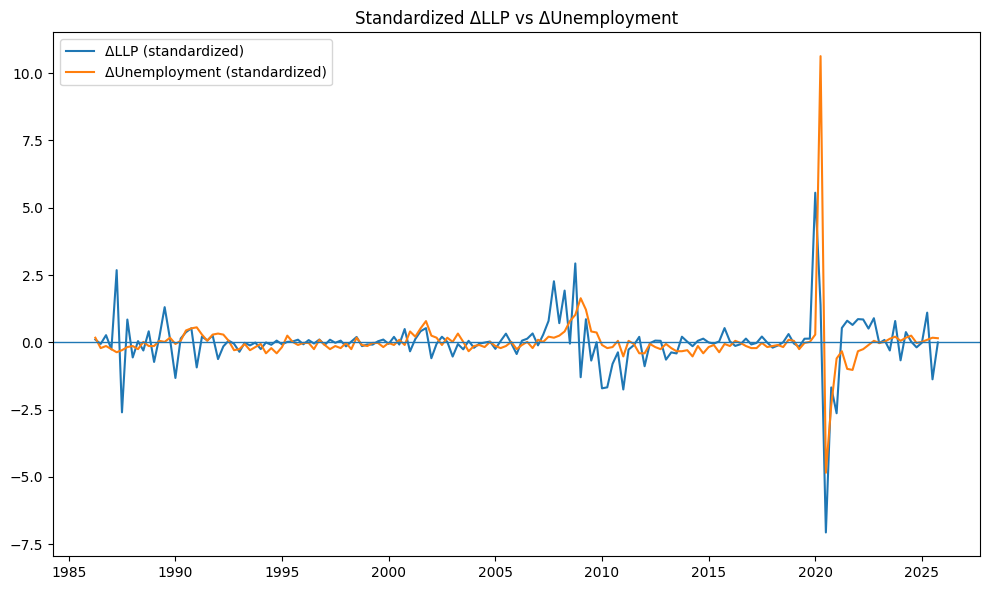

In [8]:
# Create Z Scores

df["dllp_z"] = (df["dllp"] - df["dllp"].mean()) / df["dllp"].std()
df["dunemp_z"] = (df["dunemp"] - df["dunemp"].mean()) / df["dunemp"].std()

# More readable plot

plt.figure(figsize=(10,6))
plt.plot(df.index, df["dllp_z"], label="ΔLLP (standardized)")
plt.plot(df.index, df["dunemp_z"], label="ΔUnemployment (standardized)")
plt.axhline(0, linewidth=1)
plt.legend()
plt.title("Standardized ΔLLP vs ΔUnemployment")
plt.tight_layout()
plt.show()

In [9]:
df_cc = df[["dllp", "dunemp"]].dropna()

In [10]:
# Cross-correlations for unemployment and LLP

max_lag = 8
lags = range(-max_lag, max_lag + 1)

correlations = []

for k in lags:
    if k > 0:
        corr = df_cc["dllp"].corr(df_cc["dunemp"].shift(-k))
    elif k < 0:
        corr = df_cc["dllp"].shift(k).corr(df_cc["dunemp"])
    else:
        corr = df_cc["dllp"].corr(df_cc["dunemp"])
    
    correlations.append(corr)

ccf_df = pd.DataFrame({
    "lag": list(lags),
    "correlation": correlations
})

In [11]:
peak_row = ccf_df.loc[ccf_df["correlation"].abs().idxmax()]

print("Peak lag:", peak_row["lag"])
print("Peak correlation:", peak_row["correlation"])

ccf_df.reindex(ccf_df["correlation"].abs().sort_values(ascending=False).index).head()

Peak lag: 1.0
Peak correlation: 0.4845615649972852


,lag,correlation
9,1,0.484562
7,-1,-0.382951
8,0,0.375391
5,-3,-0.246113
13,5,0.088966


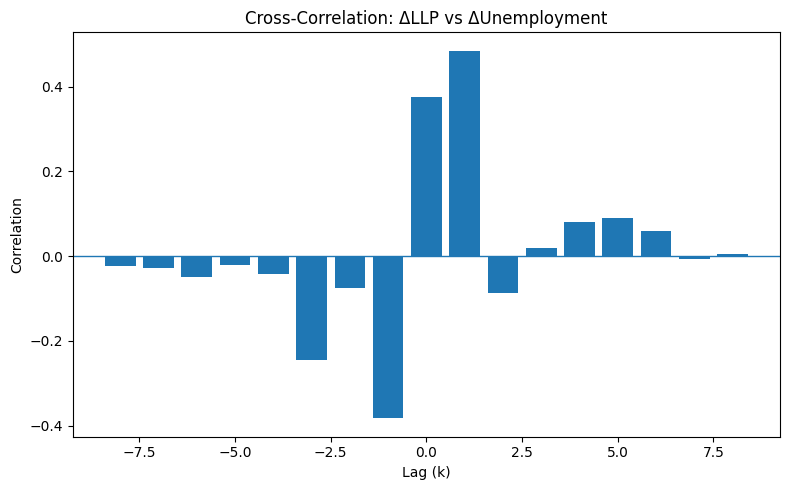

In [12]:
# Plot Lag Structure

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(ccf_df["lag"], ccf_df["correlation"])
plt.axhline(0, linewidth=1)
plt.title("Cross-Correlation: ΔLLP vs ΔUnemployment")
plt.xlabel("Lag (k)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

In [13]:
# Identify peak lag

peak_row = ccf_df.loc[ccf_df["correlation"].abs().idxmax()]

print("Peak lag:", peak_row["lag"])
print("Peak correlation:", peak_row["correlation"])

Peak lag: 1.0
Peak correlation: 0.4845615649972852


In [14]:
# Create lags


for k in range(0, 5):
    df[f"dunemp_lag{k}"] = df["dunemp"].shift(k)

In [15]:
# Regression dataset

reg_cols = ["dllp"] + [f"dunemp_lag{k}" for k in range(0,5)]

df_reg = df[reg_cols].dropna()

In [16]:
df_reg.head()
df_reg.shape

(155, 6)

In [17]:
X = df_reg[[f"dunemp_lag{k}" for k in range(0,5)]]
X = sm.add_constant(X)

y = df_reg["dllp"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   dllp   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     16.98
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           2.87e-13
Time:                        16:19:14   Log-Likelihood:                -1553.7
No. Observations:                 155   AIC:                             3119.
Df Residuals:                     149   BIC:                             3138.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.1390    447.753     -0.011      

In [18]:
model_robust = sm.OLS(y, X).fit(cov_type="HC1")
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                   dllp   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     9.404
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           8.28e-08
Time:                        16:19:14   Log-Likelihood:                -1553.7
No. Observations:                 155   AIC:                             3119.
Df Residuals:                     149   BIC:                             3138.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.1390    459.426     -0.011      

In [19]:
sum(model_robust.params[1:])

-5326.308648203099

### 1.5 - Unemployment with the addition of total loans

In [20]:
df["dllp_ratio"] = df["llp_ratio"].diff()
df["dunemp"] = df["unemployment"].diff()

In [21]:
# create lagged unemployment

for k in range(0, 5):
    df[f"dunemp_lag{k}"] = df["dunemp"].shift(k)

In [22]:
# Regression dataset

reg_cols = ["dllp_ratio"] + [f"dunemp_lag{k}" for k in range(0,5)]

df_reg = df[reg_cols].dropna()

df_reg.shape

(155, 6)

In [23]:
# Distributed lag with robust SE

X = df_reg[[f"dunemp_lag{k}" for k in range(0,5)]]
X = sm.add_constant(X)

y = df_reg["dllp_ratio"]

model_ratio = sm.OLS(y, X).fit(cov_type="HC1")

print(model_ratio.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     5.805
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           6.29e-05
Time:                        16:19:14   Log-Likelihood:                 777.71
No. Observations:                 155   AIC:                            -1543.
Df Residuals:                     149   BIC:                            -1525.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2.159e-05      0.000     -0.167      

In [24]:
sum(model_ratio.params[1:])


-0.00047181144988450507

In [25]:
# Reload new data

import pandas as pd
import statsmodels.api as sm

df = pd.read_csv(
    "../data/processed/quarterly_llp_macro.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

df = df.sort_index()

df.index.min(), df.index.max(), len(df)

(Timestamp('1986-01-01 00:00:00'), Timestamp('2025-10-01 00:00:00'), 160)

In [ ]:
# Construct all first differences - macro signals in change form

df["dllp_ratio"] = df["llp_ratio"].diff()
df["dunemp"] = df["unemployment"].diff()
df["dindpro"] = df["indpro"].diff()
df["dspread"] = df["term_spread"].diff()
df["doptimism"] = df["optimism_index"].diff()

In [27]:
# Drop missing rows

df_diff = df[[
    "dllp_ratio",
    "dunemp",
    "dindpro",
    "dspread",
    "doptimism"
]].dropna()

In [28]:
# Check shape

df_diff.shape

(159, 5)

In [29]:
# Test Opti only

for k in range(0, 4):
    df_diff[f"doptimism_lag{k}"] = df_diff["doptimism"].shift(k)

df_opt = df_diff[["dllp_ratio"] + [f"doptimism_lag{k}" for k in range(0,4)]].dropna()

In [30]:
X = df_opt[[f"doptimism_lag{k}" for k in range(0,4)]]
X = sm.add_constant(X)
y = df_opt["dllp_ratio"]

model_opt = sm.OLS(y, X).fit(cov_type="HC1")
print(model_opt.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     1.759
Date:                Sat, 21 Mar 2026   Prob (F-statistic):              0.140
Time:                        16:19:14   Log-Likelihood:                 783.12
No. Observations:                 156   AIC:                            -1556.
Df Residuals:                     151   BIC:                            -1541.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -2.26e-05      0.000     -0.

In [31]:
df.head()

,llp,unemployment,indpro,recession,term_spread,total_loans,llp_ratio,optimism_index,dllp_ratio,dunemp,dindpro,dspread,doptimism
DATE,,,,,,,,,,,,,
1986-01-01,4727.716,7.033333,55.355800,0.0,1.448000,1.436639e+06,0.003291,100.513167,NaN,NaN,NaN,NaN,NaN
1986-04-01,5545.933,7.166667,55.021467,0.0,1.277031,1.463927e+06,0.003788,101.420000,0.000498,0.133333,-0.334333,-0.170969,0.906833
1986-07-01,5254.408,6.966667,55.237800,0.0,1.621406,1.493164e+06,0.003519,99.079233,-0.000269,-0.200000,0.216333,0.344375,-2.340767
1986-10-01,7171.896,6.833333,55.857800,0.0,1.761935,1.528918e+06,0.004691,98.987867,0.001172,-0.133333,0.620000,0.140529,-0.091367
1987-01-01,5502.244,6.600000,56.608500,0.0,1.495738,1.577870e+06,0.003487,100.634667,-0.001204,-0.233333,0.750700,-0.266198,1.646800


## Multi-Signal distributed lag model

In [32]:
for k in range(0, 4):
    df_diff[f"dunemp_lag{k}"] = df_diff["dunemp"].shift(k)
    df_diff[f"dindpro_lag{k}"] = df_diff["dindpro"].shift(k)
    df_diff[f"dspread_lag{k}"] = df_diff["dspread"].shift(k)
    df_diff[f"doptimism_lag{k}"] = df_diff["doptimism"].shift(k)

In [33]:
# Regression dataset

lag_vars = []

for var in ["dunemp", "dindpro", "dspread", "doptimism"]:
    for k in range(0, 4):
        lag_vars.append(f"{var}_lag{k}")

df_reg = df_diff[["dllp_ratio"] + lag_vars].dropna()

In [34]:
X = df_reg[lag_vars]
X = sm.add_constant(X)

y = df_reg["dllp_ratio"]

model_multi = sm.OLS(y, X).fit(cov_type="HC1")

print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     3.384
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           4.85e-05
Time:                        16:19:14   Log-Likelihood:                 797.29
No. Observations:                 156   AIC:                            -1561.
Df Residuals:                     139   BIC:                            -1509.
Df Model:                          16                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const           4.519e-05      0.000      0.

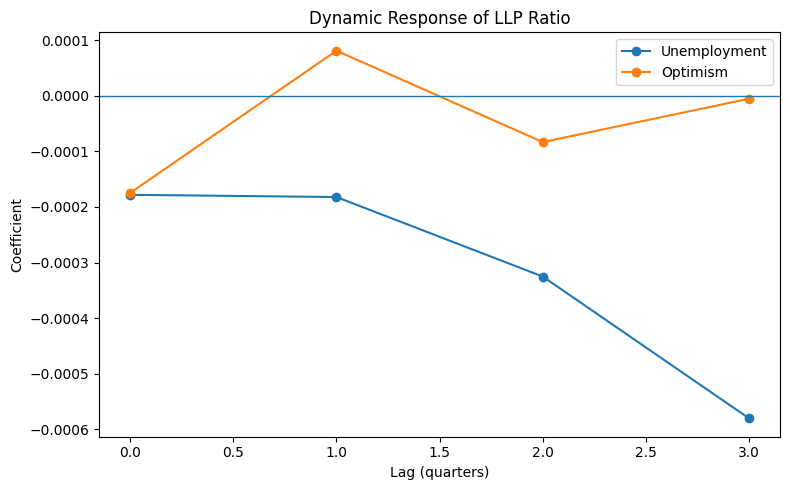

In [35]:
import matplotlib.pyplot as plt

lags = range(0, 4)

coeffs_unemp = [model_multi.params[f"dunemp_lag{k}"] for k in lags]
coeffs_opt = [model_multi.params[f"doptimism_lag{k}"] for k in lags]

plt.figure(figsize=(8,5))
plt.plot(lags, coeffs_unemp, marker='o', label="Unemployment")
plt.plot(lags, coeffs_opt, marker='o', label="Optimism")

plt.axhline(0, linewidth=1)
plt.xlabel("Lag (quarters)")
plt.ylabel("Coefficient")
plt.title("Dynamic Response of LLP Ratio")
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
# Collect lag variables

lag_vars = []
for var in ["dunemp", "dindpro", "dspread", "doptimism"]:
    for k in range(0, 4):
        lag_vars.append(f"{var}_lag{k}")

# Final regression dataset
df_reg = df_diff[["dllp_ratio"] + lag_vars].dropna()

print(df_reg.shape)

(156, 17)


In [37]:
X = df_reg[lag_vars]
X = sm.add_constant(X)

y = df_reg["dllp_ratio"]

model_multi = sm.OLS(y, X).fit(cov_type="HC1")

print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     3.384
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           4.85e-05
Time:                        16:19:14   Log-Likelihood:                 797.29
No. Observations:                 156   AIC:                            -1561.
Df Residuals:                     139   BIC:                            -1509.
Df Model:                          16                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const           4.519e-05      0.000      0.

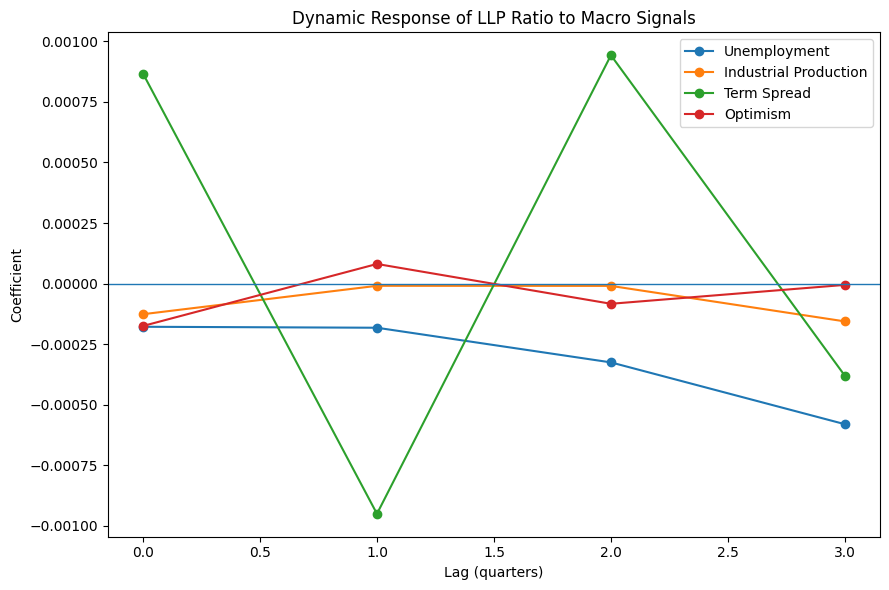

In [38]:
import matplotlib.pyplot as plt

lags = range(0, 4)

# Extract coefficients
def get_coefs(var):
    return [model_multi.params[f"{var}_lag{k}"] for k in lags]

coef_unemp = get_coefs("dunemp")
coef_indpro = get_coefs("dindpro")
coef_spread = get_coefs("dspread")
coef_optimism = get_coefs("doptimism")

# Plot
plt.figure(figsize=(9,6))

plt.plot(lags, coef_unemp, marker='o', label="Unemployment")
plt.plot(lags, coef_indpro, marker='o', label="Industrial Production")
plt.plot(lags, coef_spread, marker='o', label="Term Spread")
plt.plot(lags, coef_optimism, marker='o', label="Optimism")

plt.axhline(0, linewidth=1)
plt.xlabel("Lag (quarters)")
plt.ylabel("Coefficient")
plt.title("Dynamic Response of LLP Ratio to Macro Signals")
plt.legend()

plt.tight_layout()
plt.show()

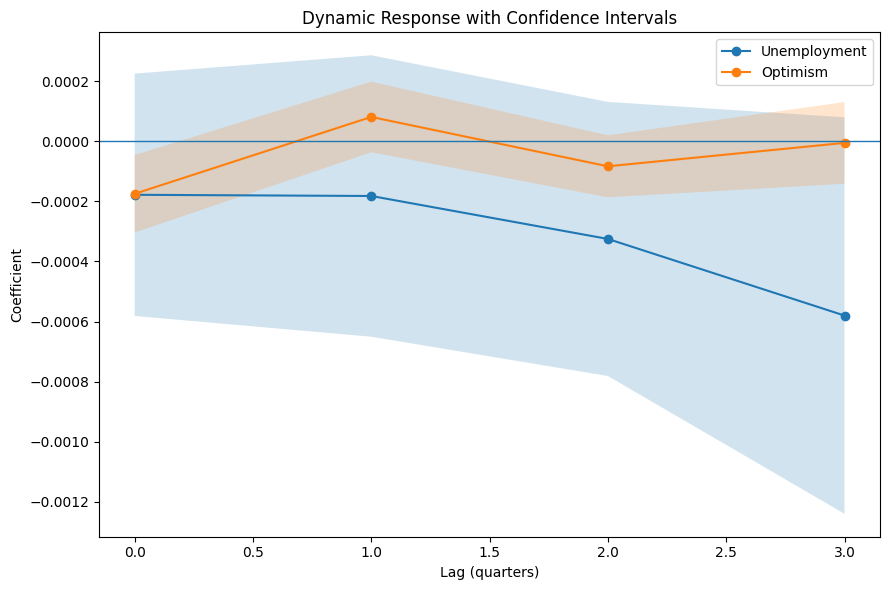

In [39]:
def get_ci(var):
    lower = []
    upper = []
    
    for k in lags:
        param = f"{var}_lag{k}"
        coef = model_multi.params[param]
        se = model_multi.bse[param]
        
        lower.append(coef - 1.96 * se)
        upper.append(coef + 1.96 * se)
    
    return lower, upper

plt.figure(figsize=(9,6))

for var, label in zip(
    ["dunemp", "doptimism"],
    ["Unemployment", "Optimism"]
):
    coef = get_coefs(var)
    lower, upper = get_ci(var)
    
    plt.plot(lags, coef, marker='o', label=label)
    plt.fill_between(lags, lower, upper, alpha=0.2)

plt.axhline(0, linewidth=1)
plt.xlabel("Lag (quarters)")
plt.ylabel("Coefficient")
plt.title("Dynamic Response with Confidence Intervals")
plt.legend()

plt.tight_layout()
plt.show()